In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
print('Libraries Ready!')

Libraries Ready!


In [ ]:
df = pd.read_csv('customer_churn.csv')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(df.head())

Rows: 1000, Columns: 8
   age  salary  balance  credit_score  tenure  products  active_member  churn
0   56  125186    84082           366      18         2              0      1
1   69   54674   150201           306      14         3              1      0
2   46   55854   128322           825       3         2              1      0
3   32   66271   132663           372      12         2              1      0
4   60   93688    11303           698       9         3              1      0


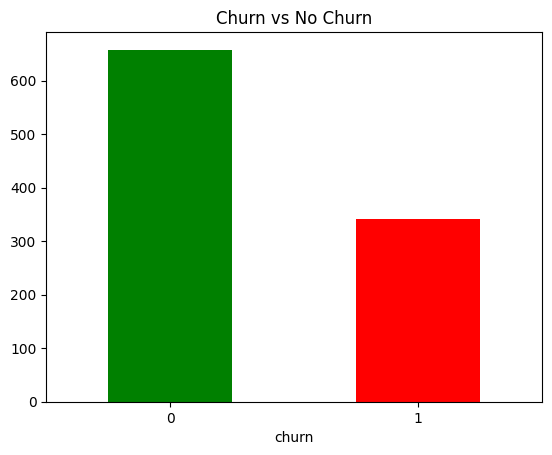

In [ ]:

df['churn'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Churn vs No Churn')
plt.xticks(rotation=0)
plt.show()

In [ ]:

X = df.drop('churn', axis=1)
Y = df['churn']
print(f'Features: {X.columns.tolist()}')
print(f'X: {len(X)} rows, Y: {len(Y)} rows')

Features: ['age', 'salary', 'balance', 'credit_score', 'tenure', 'products', 'active_member']
X: 1000 rows, Y: 1000 rows


In [ ]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)
print(f'Training: {len(X_train)} | Testing: {len(X_test)}')

Training: 800 | Testing: 200


In [ ]:

model1 = LogisticRegression()
model1.fit(X_train, Y_train)
model2 = DecisionTreeClassifier()
model2.fit(X_train, Y_train)
model3 = RandomForestClassifier()
model3.fit(X_train, Y_train)
print('Teeno Models Train Ho Gaye! ')

Teeno Models Train Ho Gaye! 


In [ ]:

acc1 = accuracy_score(Y_test, model1.predict(X_test))
acc2 = accuracy_score(Y_test, model2.predict(X_test))
acc3 = accuracy_score(Y_test, model3.predict(X_test))
print(f'Logistic Regression : {acc1*100:.2f}%')
print(f'Decision Tree       : {acc2*100:.2f}%')
print(f'Random Forest       : {acc3*100:.2f}%')

Logistic Regression : 69.50%
Decision Tree       : 65.00%
Random Forest       : 70.50%


In [ ]:

models = {'Logistic Regression': acc1, 'Decision Tree': acc2, 'Random Forest': acc3}
best = max(models, key=models.get)
print(f'Best Model: {best} ')
print(f'Accuracy: {models[best]*100:.2f}%')

Best Model: Random Forest 
Accuracy: 70.50%


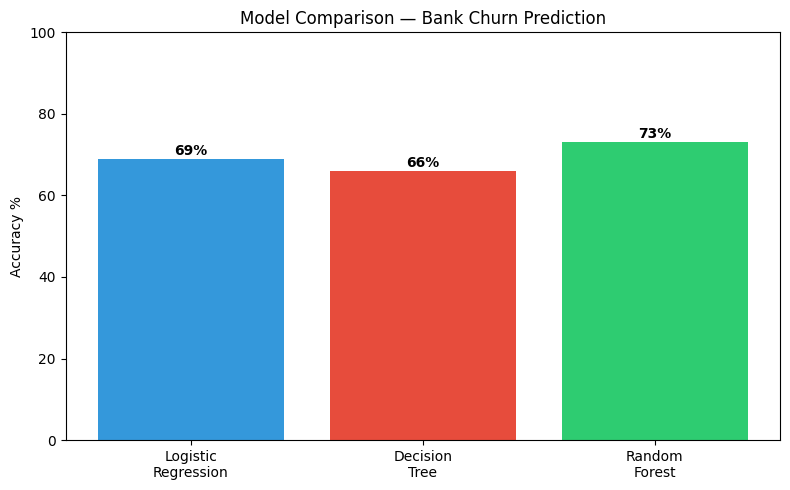

In [ ]:
models_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accuracies = [69, 66, 73]

plt.figure(figsize=(8,5))
bars = plt.bar(models_names, accuracies, color=['#3498db','#e74c3c','#2ecc71'])
plt.title('Model Comparison — Bank Churn Prediction')
plt.ylabel('Accuracy %')
plt.ylim([0, 100])


for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc}%',
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()